# Notebook 03 — PPO-LSTM sur CartPole-MaskedVelocity

**Objectif :** entraîner un agent PPO avec politique et critique **récurrents** (LSTM) sur le POMDP. Comparer à PPO-MLP du NB 02.

## Différences clés vs PPO-MLP

| Aspect | PPO-MLP | PPO-LSTM |
|---|---|---|
| Architecture | MLP simple | Encoder MLP → LSTM → têtes actor/critic |
| Buffer | obs, actions, ... | + hidden states `(h, c)` initiaux |
| Reset | aucun | reset des hidden states à chaque fin d'épisode |
| Minibatching | aléatoire sur toutes les transitions | **par envs** pour préserver l'ordre temporel |

## Pièges techniques (importants pour le rapport)

1. **Reset des hidden states** : à la fin d'un épisode, on multiplie `h, c` par `(1 - done)` pour les remettre à zéro. Sans ça, l'agent garde la mémoire d'un épisode terminé → catastrophe.

2. **Sauvegarde de l'état LSTM initial** : on doit conserver `(h_0, c_0)` au début de chaque rollout pour pouvoir **re-rouler le LSTM** lors de l'update PPO. Sans ça, les nouveaux log-probs ne correspondent pas aux anciens.

3. **Minibatching par envs** : on ne peut pas mélanger aléatoirement les transitions car ça casse l'ordre temporel. On split par envs : chaque minibatch = sous-ensemble d'envs × toute la séquence temporelle.

## Setup

In [6]:
import sys, os, random, time, json
from pathlib import Path
from dataclasses import dataclass, asdict

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.agents.ppo_lstm import AgentLSTM, PPOLSTMConfig
from src.envs.pomdp_wrappers import MaskVelocityWrapper
from src.utils.seeding import set_global_seed

ROOT = c:\Users\Pape Malick\works\ppo-recurrent-pomdp


## Configuration

In [7]:
cfg = PPOLSTMConfig(
    exp_name="ppo_lstm_cartpole_masked",
    env_id="CartPole-v1",
    use_masked_velocity=True,
    total_timesteps=300_000,
    seed=1,
)
run_name = f"{cfg.exp_name}__seed{cfg.seed}"
print(asdict(cfg))

{'exp_name': 'ppo_lstm_cartpole_masked', 'seed': 1, 'cuda': True, 'env_id': 'CartPole-v1', 'use_masked_velocity': True, 'total_timesteps': 300000, 'learning_rate': 0.00025, 'anneal_lr': True, 'num_envs': 4, 'num_steps': 128, 'gamma': 0.99, 'gae_lambda': 0.95, 'num_minibatches': 4, 'update_epochs': 4, 'norm_adv': True, 'clip_coef': 0.2, 'clip_vloss': True, 'ent_coef': 0.01, 'vf_coef': 0.5, 'max_grad_norm': 0.5, 'hidden_size': 64, 'lstm_hidden_size': 128, 'save_dir': 'results'}


## Boucle d'entraînement

Le code est plus long que pour PPO-MLP à cause de la gestion des hidden states.
**Les sections clés sont annotées dans les commentaires.**

In [8]:
set_global_seed(cfg.seed)
device = torch.device("cuda" if cfg.cuda and torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def make_env(seed, idx):
    def thunk():
        env = gym.make(cfg.env_id)
        if cfg.use_masked_velocity:
            env = MaskVelocityWrapper(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env.action_space.seed(seed + idx)
        return env
    return thunk

envs = gym.vector.SyncVectorEnv([make_env(cfg.seed, i) for i in range(cfg.num_envs)])
obs_shape = envs.single_observation_space.shape
n_actions = envs.single_action_space.n
obs_dim = int(np.prod(obs_shape))
print(f"obs_shape={obs_shape}, n_actions={n_actions}")

agent = AgentLSTM(obs_dim, n_actions, cfg.hidden_size, cfg.lstm_hidden_size).to(device)
optimizer = optim.Adam(agent.parameters(), lr=cfg.learning_rate, eps=1e-5)

# --- Buffers ---
obs_buf = torch.zeros((cfg.num_steps, cfg.num_envs) + obs_shape, device=device)
actions_buf = torch.zeros((cfg.num_steps, cfg.num_envs), device=device)
logprobs_buf = torch.zeros((cfg.num_steps, cfg.num_envs), device=device)
rewards_buf = torch.zeros((cfg.num_steps, cfg.num_envs), device=device)
dones_buf = torch.zeros((cfg.num_steps, cfg.num_envs), device=device)
values_buf = torch.zeros((cfg.num_steps, cfg.num_envs), device=device)

# État LSTM persistant entre les rollouts
next_lstm_state = agent.initial_state(cfg.num_envs, device)

history = {"step": [], "episodic_return": []}
global_step = 0
start = time.time()

next_obs, _ = envs.reset(seed=cfg.seed)
next_obs = torch.tensor(next_obs, dtype=torch.float32, device=device)
next_done = torch.zeros(cfg.num_envs, device=device)

for iteration in range(1, cfg.num_iterations + 1):
    if cfg.anneal_lr:
        frac = 1.0 - (iteration - 1) / cfg.num_iterations
        for pg in optimizer.param_groups: pg["lr"] = frac * cfg.learning_rate

    # CRITIQUE #2 : sauvegarder l'état LSTM initial de cette itération
    # → indispensable pour pouvoir re-rouler le LSTM lors de l'update.
    initial_lstm_state = (next_lstm_state[0].clone(), next_lstm_state[1].clone())

    # === ROLLOUT ===
    for step in range(cfg.num_steps):
        global_step += cfg.num_envs
        obs_buf[step] = next_obs
        dones_buf[step] = next_done

        with torch.no_grad():
            action, logprob, _, value, next_lstm_state = agent.get_action_and_value(
                next_obs, next_lstm_state, next_done, seq_len=1
            )
            values_buf[step] = value.flatten()
        actions_buf[step] = action
        logprobs_buf[step] = logprob

        obs_np, reward, term, trunc, info = envs.step(action.cpu().numpy())
        rewards_buf[step] = torch.tensor(reward, dtype=torch.float32, device=device)
        done_np = np.logical_or(term, trunc)
        next_obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
        next_done = torch.tensor(done_np, dtype=torch.float32, device=device)

        if "final_info" in info:
            for ei in info["final_info"]:
                if ei and "episode" in ei:
                    history["step"].append(global_step)
                    history["episodic_return"].append(float(ei["episode"]["r"]))
        elif "episode" in info and "_episode" in info:
            mask = info["_episode"]
            if np.any(mask):
                for idx in np.where(mask)[0]:
                    history["step"].append(global_step)
                    history["episodic_return"].append(float(info["episode"]["r"][idx]))

    # === GAE ===
    with torch.no_grad():
        next_value = agent.get_value(next_obs, next_lstm_state, next_done).reshape(1, -1)
        advantages = torch.zeros_like(rewards_buf)
        lastgaelam = 0.0
        for t in reversed(range(cfg.num_steps)):
            if t == cfg.num_steps - 1:
                nextnonterm = 1.0 - next_done; nextvals = next_value
            else:
                nextnonterm = 1.0 - dones_buf[t+1]; nextvals = values_buf[t+1]
            delta = rewards_buf[t] + cfg.gamma * nextvals * nextnonterm - values_buf[t]
            advantages[t] = lastgaelam = delta + cfg.gamma * cfg.gae_lambda * nextnonterm * lastgaelam
        returns = advantages + values_buf

    # === UPDATE PPO : MINIBATCHING PAR ENVS ===
    # CRITIQUE #3 : on NE peut PAS mélanger les transitions individuelles.
    # On mélange les ENVS (chaque env = une séquence temporelle cohérente).
    assert cfg.num_envs % cfg.num_minibatches == 0
    envinds = np.arange(cfg.num_envs)
    flatinds = np.arange(cfg.batch_size).reshape(cfg.num_steps, cfg.num_envs)

    for epoch in range(cfg.update_epochs):
        np.random.shuffle(envinds)
        for s in range(0, cfg.num_envs, cfg.envs_per_minibatch):
            mb_env_inds = envinds[s : s + cfg.envs_per_minibatch]
            # On reprend l'état LSTM initial pour CES envs uniquement
            mb_lstm_state = (
                initial_lstm_state[0][:, mb_env_inds],
                initial_lstm_state[1][:, mb_env_inds],
            )
            _, newlogprob, entropy, newvalue, _ = agent.get_action_and_value(
                obs_buf[:, mb_env_inds].reshape(-1, *obs_shape),
                mb_lstm_state,
                dones_buf[:, mb_env_inds].reshape(-1),
                action=actions_buf[:, mb_env_inds].reshape(-1).long(),
                seq_len=cfg.num_steps,
            )
            logratio = newlogprob - logprobs_buf[:, mb_env_inds].reshape(-1)
            ratio = logratio.exp()
            mb_adv = advantages[:, mb_env_inds].reshape(-1)
            if cfg.norm_adv:
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
            pg_loss1 = -mb_adv * ratio
            pg_loss2 = -mb_adv * torch.clamp(ratio, 1-cfg.clip_coef, 1+cfg.clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()
            newvalue = newvalue.view(-1)
            mb_ret = returns[:, mb_env_inds].reshape(-1)
            mb_val = values_buf[:, mb_env_inds].reshape(-1)
            if cfg.clip_vloss:
                v_clipped = mb_val + torch.clamp(newvalue - mb_val, -cfg.clip_coef, cfg.clip_coef)
                v_loss = 0.5 * torch.max((newvalue - mb_ret)**2, (v_clipped - mb_ret)**2).mean()
            else:
                v_loss = 0.5 * ((newvalue - mb_ret)**2).mean()
            ent_loss = entropy.mean()
            loss = pg_loss - cfg.ent_coef * ent_loss + cfg.vf_coef * v_loss
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), cfg.max_grad_norm)
            optimizer.step()

    if iteration % 20 == 0 or iteration == 1:
        recent = history["episodic_return"][-20:] if history["episodic_return"] else [0]
        sps = int(global_step / (time.time() - start))
        print(f"iter {iteration:4d} | step {global_step:7d} | return(20)={np.mean(recent):6.1f} | SPS={sps}")

envs.close()
print(f"\nDurée : {time.time()-start:.1f}s")

Device: cpu
obs_shape=(2,), n_actions=2
iter    1 | step     512 | return(20)=  18.8 | SPS=207
iter   20 | step   10240 | return(20)=  20.9 | SPS=334
iter   40 | step   20480 | return(20)=  24.9 | SPS=353
iter   60 | step   30720 | return(20)=  23.1 | SPS=364
iter   80 | step   40960 | return(20)=  23.5 | SPS=369
iter  100 | step   51200 | return(20)=  23.8 | SPS=371
iter  120 | step   61440 | return(20)=  19.2 | SPS=373
iter  140 | step   71680 | return(20)=  24.9 | SPS=374
iter  160 | step   81920 | return(20)=  22.9 | SPS=374
iter  180 | step   92160 | return(20)=  21.6 | SPS=374
iter  200 | step  102400 | return(20)=  19.4 | SPS=374
iter  220 | step  112640 | return(20)=  21.7 | SPS=375
iter  240 | step  122880 | return(20)=  21.2 | SPS=376
iter  260 | step  133120 | return(20)=  21.1 | SPS=364
iter  280 | step  143360 | return(20)=  21.5 | SPS=343
iter  300 | step  153600 | return(20)=  24.1 | SPS=333
iter  320 | step  163840 | return(20)=  22.1 | SPS=327
iter  340 | step  174080 

## Courbe d'apprentissage

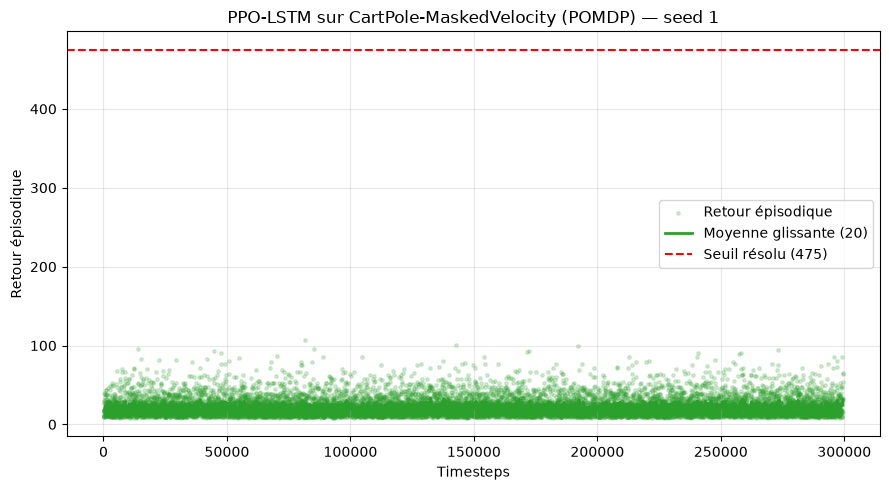

Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv\ppo_lstm_cartpole_masked__seed1.png

Retour moyen sur les 50 derniers ep : 27.82


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
steps = np.array(history["step"])
returns = np.array(history["episodic_return"])
ax.scatter(steps, returns, s=6, alpha=0.2, color="C2", label="Retour épisodique")
if len(returns) >= 20:
    smooth = np.convolve(returns, np.ones(20)/20, mode="valid")
    ax.plot(steps[19:], smooth, color="C2", linewidth=2, label="Moyenne glissante (20)")
ax.axhline(475, color="red", linestyle="--", label="Seuil résolu (475)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Retour épisodique")
ax.set_title(f"PPO-LSTM sur CartPole-MaskedVelocity (POMDP) — seed {cfg.seed}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = ROOT / "results" / "csv" / f"{run_name}.png"
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Figure → {fig_path}")
print(f"\nRetour moyen sur les 50 derniers ep : {np.mean(returns[-50:]):.2f}")

## Sauvegarde

In [10]:
df = pd.DataFrame({"step": history["step"], "return": history["episodic_return"]})
df["config"] = "PPO-LSTM / CartPole-Masked (POMDP)"
csv_path = ROOT / "results" / "csv" / f"{run_name}.csv"
df.to_csv(csv_path, index=False)
print(f"CSV → {csv_path}")

model_path = ROOT / "results" / "models" / f"{run_name}.pt"
torch.save(agent.state_dict(), model_path)
print(f"Modèle → {model_path}")

CSV → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv\ppo_lstm_cartpole_masked__seed1.csv
Modèle → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\models\ppo_lstm_cartpole_masked__seed1.pt
